### **Train FHMM Step by Step**

**Import**

In [1]:
import sys
import os
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

**Set the project path**

In [2]:
base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(base_dir)
print(f"base_dir = {base_dir}")

data_dir = os.path.join(base_dir, 'data', 'processed_data')
print(f"data_dir = {data_dir}")

print(f"The files in data_dir: {os.listdir(data_dir)}")

base_dir = d:\Document\2025.2\IT3191E_Machine_Learning\ML_FinalProject_NILM_REFIT
data_dir = d:\Document\2025.2\IT3191E_Machine_Learning\ML_FinalProject_NILM_REFIT\data\processed_data
The files in data_dir: ['House2_full.csv', 'House2_part1.csv', 'House2_part2.csv', 'House2_part3.csv', 'House2_part4.csv', 'House2_part5.csv']


**Combine 5 CSV files into one `DataFrame`**

In [3]:
print("Reading data...")
dfs = []
for i in range(1, 6):  # i = 1, 2, 3, 4, 5
    filepath = os.path.join(data_dir, f'House2_part{i}.csv')
    print(f"  Reading House2_part{i}.csv...")
    df_part = pd.read_csv(filepath)
    dfs.append(df_part)

df = pd.concat(dfs, axis=0, ignore_index=True)
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")
print(f"Column names: {df.columns.tolist()}")

Reading data...
  Reading House2_part1.csv...
  Reading House2_part2.csv...
  Reading House2_part3.csv...
  Reading House2_part4.csv...
  Reading House2_part5.csv...
Number of rows: 5,733,526
Number of columns: 12
Column names: ['Time', 'Unix', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']


**Save the merged df to a `.csv` file**

In [4]:
full_path = os.path.join(data_dir, 'House2_full.csv')

if not os.path.exists(full_path):
    print("Saving House2_full.csv...")
    df.to_csv(full_path, index=False)
    print(f"Saved at: {full_path}")
else:
    print(f"The file already exists")
    print("Reloading from House2_full.csv...")
    df = pd.read_csv(full_path)
    print(f"Loaded: {len(df):,} rows")


The file already exists
Reloading from House2_full.csv...
Loaded: 5,733,526 rows


**Process the `Time` column**

In [5]:
df['Time'] = pd.to_datetime(df['Time'])

print(f"Time data type: {df['Time'].dtype}") 
print(f"Start time: {df['Time'].min()}")
print(f"End time: {df['Time'].max()}")
print(f"Time interval: {df['Time'].max() - df['Time'].min()}")

time_diff = df['Time'].diff().dropna()
print(f"Mean distance between samples: {time_diff.mean()}")
print(f"Most common distance: {time_diff.mode()[0]}")

Time data type: datetime64[us]
Start time: 2013-09-17 22:08:11
End time: 2015-05-28 08:05:43
Time interval: 617 days 09:57:32
Mean distance between samples: 0 days 00:00:09.303988
Most common distance: 0 days 00:00:07


**Calculate `Appliance_Others`**

In [6]:
appliance_cols = ['Appliance1', 'Appliance2', 'Appliance3', 
                  'Appliance4', 'Appliance5', 'Appliance6',
                  'Appliance7', 'Appliance8', 'Appliance9']

df['sum_9_appliances'] = df[appliance_cols].sum(axis=1)

df['Appliance_Others'] = df['Aggregate'] - df['sum_9_appliances']

negative_count = (df['Appliance_Others'] < 0).sum()
print(f"Number of rows with Appliance_Others < 0 (to be deleted): {negative_count:,}")

df = df[df['Appliance_Others'] >= 0].copy()
print(f"The {negative_count:,} line has been removed. The current minimum value is: {df['Appliance_Others'].min()}")

df.drop(columns=['sum_9_appliances'], inplace=True)

print("Appliance_Others Distribution BEFORE Filtering")
print(df['Appliance_Others'].describe(percentiles=[.01, .25, .5, .75, .99, .999]))
print(f"\nNumber of negative rows : {(df['Appliance_Others'] < 0).sum():,}")
print(f"Absolute Max: {df['Appliance_Others'].max():.1f} W")

upper_bound = df['Aggregate'].quantile(0.999)
print(f"99.9th percentile of Aggregate = {upper_bound:.1f} W")
print(f"Max Aggregate in dataset= {df['Aggregate'].max():.1f} W\n")

df['Appliance_Others'] = df['Appliance_Others'].clip(lower=0, upper=upper_bound)

print(f"Summary of Appliance_Others AFTER edge lamination")
print(df['Appliance_Others'].describe())

Number of rows with Appliance_Others < 0 (to be deleted): 28,444
The 28,444 line has been removed. The current minimum value is: 0
Appliance_Others Distribution BEFORE Filtering
count    5.705082e+06
mean     3.214029e+02
std      9.227989e+02
min      0.000000e+00
1%       5.200000e+01
25%      8.300000e+01
50%      1.120000e+02
75%      2.300000e+02
99%      3.456000e+03
99.9%    1.034700e+04
max      2.438700e+04
Name: Appliance_Others, dtype: float64

Number of negative rows : 0
Absolute Max: 24387.0 W
99.9th percentile of Aggregate = 10503.8 W
Max Aggregate in dataset= 24595.0 W

Summary of Appliance_Others AFTER edge lamination
count    5.705082e+06
mean     3.209236e+02
std      9.169878e+02
min      0.000000e+00
25%      8.300000e+01
50%      1.120000e+02
75%      2.300000e+02
max      1.050376e+04
Name: Appliance_Others, dtype: float64


**Add time features to the data.**

Why are time features needed?

- Washing machines often run between 8-10 AM or 7-9 PM.

- Microwaves are often used during mealtimes (12 PM, 6 PM).

- When the model knows "it's 3 AM," it will predict fewer appliances will be turned on.

In [7]:
df['hour'] = df['Time'].dt.hour
df['minute'] = df['Time'].dt.minute
df['dayofweek'] = df['Time'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

print("Time features added")
print(df[['Time', 'hour', 'minute', 'dayofweek', 'is_weekend']].head(3))

Time features added
                 Time  hour  minute  dayofweek  is_weekend
0 2013-09-17 22:08:11    22       8          1           0
1 2013-09-17 22:08:18    22       8          1           0
2 2013-09-17 22:08:26    22       8          1           0


**Divide train/val/test in chronological order (70/10/20)**

In [8]:
df = df.sort_values('Time').reset_index(drop=True)

total_rows = len(df)
train_end  = int(total_rows * 0.70)
val_end    = int(total_rows * 0.80)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()  

print(f"Total rows: {total_rows:,}")
print(f"Train: {len(df_train):,} rows ({len(df_train)/total_rows*100:.1f}%)")
print(f"Val: {len(df_val):,} rows ({len(df_val)/total_rows*100:.1f}%)")
print(f"Test: {len(df_test):,} rows ({len(df_test)/total_rows*100:.1f}%)")
print(f"\nTrain: {df_train['Time'].min()} → {df_train['Time'].max()}")
print(f"Val: {df_val['Time'].min()} → {df_val['Time'].max()}")
print(f"Test: {df_test['Time'].min()} → {df_test['Time'].max()}")

assert df_train['Time'].max() < df_val['Time'].min()
assert df_val['Time'].max()   < df_test['Time'].min()
print("\nNo overlap between sets")

Total rows: 5,705,082
Train: 3,993,557 rows (70.0%)
Val: 570,508 rows (10.0%)
Test: 1,141,017 rows (20.0%)

Train: 2013-09-17 22:08:11 → 2014-12-27 07:02:28
Val: 2014-12-27 07:02:35 → 2015-02-10 05:23:26
Test: 2015-02-10 05:23:33 → 2015-05-28 08:05:43

No overlap between sets


**Separate $X$ (features) and $y$ (targets) for train/val/test**

After this data splitting step:

|Variable|Function|
|-|-|
|`y_train`|`fit()` - train model|
|`agg_val`, `y_val`|grid search — select `n_states`/`n_iter`|
|`agg_test`, `y_test`|Final evaluation — OPENED ONLY ONCE|

In [9]:
target_cols = ['Appliance1', 'Appliance2', 'Appliance3',
               'Appliance4', 'Appliance5', 'Appliance6',
               'Appliance7', 'Appliance8', 'Appliance9',
               'Appliance_Others']

y_train = df_train[target_cols]

agg_val = df_val['Aggregate'].values
y_val   = df_val[target_cols]

agg_test = df_test['Aggregate'].values
y_test  = df_test[target_cols]

print("Sizes of the sets: ")
print(f"  y_train:  {y_train.shape}")
print(f"  agg_val:  {agg_val.shape}     y_val:   {y_val.shape}")
print(f"  agg_test: {agg_test.shape}   y_test:  {y_test.shape}")


Sizes of the sets: 
  y_train:  (3993557, 10)
  agg_val:  (570508,)     y_val:   (570508, 10)
  agg_test: (1141017,)   y_test:  (1141017, 10)


**Define the FHMM class**

Factorial HMM uses mean-field approximation.

Train K independent HMMs (K = number of devices).

Idea:

- Each device = 1 separate HMM

- Train each HMM at its own power level

- When predicting: use Aggregate to find the best hidden state

Mean-Field Residual Inference (Coordinate Descent) - Predict the power output of each appliance from Aggregate

- Loop 1, appliance_A (refrigerator):

    - other = appliance_B_est + appliance_C_est + ... = 2300W

    - resid  = agg - other = 2500 - 2300 = 200W

    - states = HMM_refrigerator.predict([200W])

    - refrigerator_est = 150W  (state ON)

- Repeat this process for each appliance, then repeat it twice to complete the cycle.

In [20]:
from hmmlearn import hmm
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

OTHERS_COL = 'Appliance_Others'

class SimpleFHMM:
    def __init__(self, n_states_per_appliance: dict = None, n_states: int = 2, n_iter: int = 100):
        self.n_states_per_appliance = n_states_per_appliance or {}
        self.n_states = n_states
        self.n_iter = n_iter
        self.models = {}
        self.is_fitted = False
    
    def _get_n_states(self, col_name):
        return self.n_states_per_appliance.get(col_name, self.n_states)
    
    def fit(self, y_train: pd.DataFrame):
        # Chỉ train HMM cho các thiết bị THỰC (bỏ qua Appliance_Others)
        train_cols = [c for c in y_train.columns if c != OTHERS_COL]
        print(f"Training {len(train_cols)} HMM models (excluding {OTHERS_COL})...")
        
        def train_single_hmm(col_name, obs_data, n_states, n_iter):
            model = hmm.GaussianHMM(
                n_components=n_states,
                covariance_type="diag",
                n_iter=n_iter,
                random_state=42
            )
            model.fit(obs_data)
            return col_name, model

        results = Parallel(n_jobs=-2, verbose=5)(
            delayed(train_single_hmm)(
                col, y_train[col].values.reshape(-1, 1),
                self._get_n_states(col), self.n_iter
            )
            for col in train_cols
        )

        for col, trained_model in results:
            self.models[col] = trained_model
            means = sorted(trained_model.means_.flatten().round(1))
            print(f"Done [{col}] (n_states={trained_model.n_components}): {means}")
        
        self.is_fitted = True
        print("\nTraining complete!")
        return self
  
    def predict(self, agg_power: np.ndarray, n_coord_iter: int = 5) -> pd.DataFrame:
        if not self.is_fitted:
            raise RuntimeError("Not yet trained! Call fit() first.")

        cols = list(self.models.keys())  # Chỉ có 9 thiết bị thực
        N = len(agg_power)

        pred_power = {
            col: np.full(N, max(self.models[col].means_.min(), 0.0))
            for col in cols
        }

        for _iter in range(n_coord_iter):
            for col in cols:
                model = self.models[col]
                other_power = sum(pred_power[c] for c in cols if c != col)
                residual = (agg_power - other_power).clip(min=0)
                states = model.predict(residual.reshape(-1, 1))
                pred_power[col] = np.array(
                    [model.means_[s, 0] for s in states]
                ).clip(min=0)

        # Appliance_Others = Aggregate - tổng 9 thiết bị (luôn >= 0)
        sum_9 = sum(pred_power[c] for c in cols)
        pred_power[OTHERS_COL] = (agg_power - sum_9).clip(min=0)

        return pd.DataFrame(pred_power)

**Train model**

The dataset is very large, so training will take a long time. For quick testing, use the first 200,000 points.

Once the model is stable, retrain it with the full dataset.

In [21]:
QUICK_TRAIN = True

if QUICK_TRAIN:
    y_train_subset = y_train.iloc[:200_000]
    print(f"Use {len(y_train_subset):,} instances for training (quick mode)")
else:
    y_train_subset = y_train
    print(f"Use full {len(y_train_subset):,} instances for training")

fhmm = SimpleFHMM(n_states=2, n_iter=100)
fhmm.fit(y_train_subset)

Use 200,000 instances for training (quick mode)
Training 9 HMM models (excluding Appliance_Others)...


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-2)]: Done   2 out of   9 | elapsed:    6.7s remaining:   23.6s
[Parallel(n_jobs=-2)]: Done   4 out of   9 | elapsed:    7.2s remaining:    9.0s
[Parallel(n_jobs=-2)]: Done   6 out of   9 | elapsed:    7.5s remaining:    3.7s


Done [Appliance1] (n_states=2): [np.float64(4.8), np.float64(85.5)]
Done [Appliance2] (n_states=2): [np.float64(3.3), np.float64(2056.1)]
Done [Appliance3] (n_states=2): [np.float64(3.5), np.float64(2203.6)]
Done [Appliance4] (n_states=2): [np.float64(0.4), np.float64(46.9)]
Done [Appliance5] (n_states=2): [np.float64(0.0), np.float64(441.5)]
Done [Appliance6] (n_states=2): [np.float64(0.0), np.float64(672.0)]
Done [Appliance7] (n_states=2): [np.float64(0.0), np.float64(17.9)]
Done [Appliance8] (n_states=2): [np.float64(0.0), np.float64(2336.5)]
Done [Appliance9] (n_states=2): [np.float64(0.0), np.float64(49.9)]

Training complete!


[Parallel(n_jobs=-2)]: Done   9 out of   9 | elapsed:    9.1s finished


**Inspect the HMM models**

In [22]:
print("Information about the trained models.")

for col, model in fhmm.models.items():
    means = sorted(model.means_.flatten()) 
    print(f"\n{col}:")
    print(f"  State means (W): {[f'{m:.1f}' for m in means]}")
    print(f"  Transition matrix:")
    for row in model.transmat_:
        print(f"    {[f'{p:.3f}' for p in row]}")

Information about the trained models.

Appliance1:
  State means (W): ['4.8', '85.5']
  Transition matrix:
    ['0.998', '0.002']
    ['0.003', '0.997']

Appliance2:
  State means (W): ['3.3', '2056.1']
  Transition matrix:
    ['1.000', '0.000']
    ['0.005', '0.995']

Appliance3:
  State means (W): ['3.5', '2203.6']
  Transition matrix:
    ['1.000', '0.000']
    ['0.010', '0.990']

Appliance4:
  State means (W): ['0.4', '46.9']
  Transition matrix:
    ['1.000', '0.000']
    ['0.002', '0.998']

Appliance5:
  State means (W): ['0.0', '441.5']
  Transition matrix:
    ['1.000', '0.000']
    ['0.063', '0.937']

Appliance6:
  State means (W): ['0.0', '672.0']
  Transition matrix:
    ['1.000', '0.000']
    ['0.046', '0.954']

Appliance7:
  State means (W): ['0.0', '17.9']
  Transition matrix:
    ['1.000', '0.000']
    ['0.001', '0.999']

Appliance8:
  State means (W): ['0.0', '2336.5']
  Transition matrix:
    ['0.939', '0.061']
    ['0.001', '0.999']

Appliance9:
  State means (W): ['

**Grid Search — find the best `n_states` and `n_iter`**

In [23]:
from sklearn.metrics import mean_absolute_error

CANDIDATE_STATES = [2, 3, 4, 5, 6]
N_ITER_FIXED = 100
TRAIN_SUBSET = 200_000
y_train_sub = y_train.iloc[:TRAIN_SUBSET]

tunable_cols = [c for c in target_cols if c != OTHERS_COL]

print("=" * 70)
print("GRID SEARCH — TÌM n_states TỐI ƯU CHO TỪNG THIẾT BỊ")
print("=" * 70)

best_n_states_per_appliance = {}

for col in tunable_cols:
    print(f"\n--- {col} ---")
    best_mae = float('inf')
    best_ns = 2
    
    for ns in CANDIDATE_STATES:
        model = hmm.GaussianHMM(
            n_components=ns, covariance_type="diag",
            n_iter=N_ITER_FIXED, random_state=42
        )
        # Train trên dữ liệu CỦA CHÍNH thiết bị đó
        model.fit(y_train_sub[col].values.reshape(-1, 1))
        
        # Đánh giá trên dữ liệu CỦA CHÍNH thiết bị đó (tập Val)
        # → Đo lường khả năng mô hình hóa hành vi thiết bị
        states = model.predict(y_val[col].values.reshape(-1, 1))
        pred = np.array([model.means_[s, 0] for s in states]).clip(min=0)
        
        mae = mean_absolute_error(y_val[col].values, pred)
        means = sorted(model.means_.flatten().round(1))
        print(f"  n_states={ns}  MAE={mae:.2f}W  means={means}")
        
        if mae < best_mae:
            best_mae = mae
            best_ns = ns
    
    best_n_states_per_appliance[col] = best_ns
    print(f"  >>> BEST: n_states={best_ns}, MAE={best_mae:.2f}W")

print("\n" + "=" * 70)
print("KẾT QUẢ TỔNG HỢP:")
for col, ns in best_n_states_per_appliance.items():
    print(f"  {col}: n_states = {ns}")


GRID SEARCH — TÌM n_states TỐI ƯU CHO TỪNG THIẾT BỊ

--- Appliance1 ---
  n_states=2  MAE=5.47W  means=[np.float64(4.8), np.float64(85.5)]
  n_states=3  MAE=2.25W  means=[np.float64(1.0), np.float64(1.0), np.float64(87.3)]
  n_states=4  MAE=1.94W  means=[np.float64(1.0), np.float64(85.1), np.float64(107.4), np.float64(776.8)]
  n_states=5  MAE=1.78W  means=[np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(85.1), np.float64(116.5)]
  n_states=6  MAE=1.77W  means=[np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(85.0), np.float64(115.7), np.float64(784.6)]
  >>> BEST: n_states=6, MAE=1.77W

--- Appliance2 ---


Model is not converging.  Current: -908431.5292608686 is not greater than -908431.5292570484. Delta is -3.820168785750866e-06


  n_states=2  MAE=6.91W  means=[np.float64(3.3), np.float64(2056.1)]
  n_states=3  MAE=3.38W  means=[np.float64(0.0), np.float64(81.3), np.float64(2056.1)]
  n_states=4  MAE=2.69W  means=[np.float64(0.0), np.float64(5.4), np.float64(103.9), np.float64(2056.1)]
  n_states=5  MAE=2.69W  means=[np.float64(0.0), np.float64(5.4), np.float64(103.9), np.float64(2055.6), np.float64(2056.5)]
  n_states=6  MAE=3.37W  means=[np.float64(0.0), np.float64(0.0), np.float64(2.0), np.float64(81.3), np.float64(2053.7), np.float64(2232.7)]
  >>> BEST: n_states=4, MAE=2.69W

--- Appliance3 ---
  n_states=2  MAE=8.30W  means=[np.float64(3.5), np.float64(2203.6)]
  n_states=3  MAE=2.29W  means=[np.float64(0.0), np.float64(63.2), np.float64(2203.6)]


Model is not converging.  Current: 1311305.9152271885 is not greater than 1311305.9702550324. Delta is -0.05502784391865134


  n_states=4  MAE=2.29W  means=[np.float64(0.0), np.float64(63.2), np.float64(2203.6), np.float64(2206.1)]
  n_states=5  MAE=1.74W  means=[np.float64(0.0), np.float64(0.0), np.float64(63.2), np.float64(2184.0), np.float64(2226.5)]
  n_states=6  MAE=1.23W  means=[np.float64(0.0), np.float64(17.3), np.float64(18.1), np.float64(71.1), np.float64(2184.0), np.float64(2226.4)]
  >>> BEST: n_states=6, MAE=1.23W

--- Appliance4 ---
  n_states=2  MAE=1.08W  means=[np.float64(0.4), np.float64(46.9)]
  n_states=3  MAE=0.55W  means=[np.float64(0.0), np.float64(0.0), np.float64(45.2)]
  n_states=4  MAE=1.13W  means=[np.float64(0.0), np.float64(27.3), np.float64(46.5), np.float64(49.0)]
  n_states=5  MAE=0.97W  means=[np.float64(0.0), np.float64(14.8), np.float64(31.4), np.float64(46.4), np.float64(48.2)]
  n_states=6  MAE=1.43W  means=[np.float64(0.0), np.float64(17.9), np.float64(29.3), np.float64(46.4), np.float64(48.2), np.float64(54.2)]
  >>> BEST: n_states=3, MAE=0.55W

--- Appliance5 ---
  n_

...

  n_states=2  MAE=0.32W  means=[np.float64(0.0), np.float64(17.9)]
  n_states=3  MAE=0.33W  means=[np.float64(0.0), np.float64(3.5), np.float64(17.9)]
  n_states=4  MAE=0.47W  means=[np.float64(0.0), np.float64(17.4), np.float64(19.8), np.float64(81.0)]
  n_states=5  MAE=0.47W  means=[np.float64(0.0), np.float64(0.0), np.float64(17.4), np.float64(19.8), np.float64(81.0)]


Model is not converging.  Current: 1365106.3568665346 is not greater than 1365106.3568685441. Delta is -2.0095612853765488e-06


  n_states=6  MAE=0.32W  means=[np.float64(0.0), np.float64(3.0), np.float64(4.0), np.float64(17.9), np.float64(49.0), np.float64(81.0)]
  >>> BEST: n_states=6, MAE=0.32W

--- Appliance8 ---
  n_states=2  MAE=7.51W  means=[np.float64(0.0), np.float64(2336.5)]


Model is not converging.  Current: 1470837.873384479 is not greater than 1470837.8735324454. Delta is -0.00014796643517911434


  n_states=3  MAE=0.45W  means=[np.float64(0.0), np.float64(45.1), np.float64(2719.6)]
  n_states=4  MAE=0.32W  means=[np.float64(0.0), np.float64(45.1), np.float64(2685.4), np.float64(2746.6)]
  n_states=5  MAE=0.32W  means=[np.float64(0.0), np.float64(0.0), np.float64(45.1), np.float64(2684.9), np.float64(2746.2)]
  n_states=6  MAE=0.44W  means=[np.float64(0.0), np.float64(1.0), np.float64(34.0), np.float64(569.8), np.float64(2687.1), np.float64(2747.9)]
  >>> BEST: n_states=4, MAE=0.32W

--- Appliance9 ---
  n_states=2  MAE=0.44W  means=[np.float64(0.0), np.float64(49.9)]
  n_states=3  MAE=0.15W  means=[np.float64(0.0), np.float64(38.9), np.float64(79.2)]
  n_states=4  MAE=0.15W  means=[np.float64(0.0), np.float64(38.9), np.float64(78.6), np.float64(128.0)]
  n_states=5  MAE=0.09W  means=[np.float64(0.0), np.float64(38.8), np.float64(69.5), np.float64(81.9), np.float64(128.0)]
  n_states=6  MAE=0.16W  means=[np.float64(0.0), np.float64(38.9), np.float64(62.6), np.float64(81.9), np.f

**Select the best configuration and retrain on the ENTIRE train set**

In [24]:
print("Best n_states for each appliance:")
for col, ns in best_n_states_per_appliance.items():
    print(f"  {col}: n_states={ns}")

N_ITER_FIXED = 100

print(f"\nTraining best model on entire {len(y_train):,} instances...")

best_model = SimpleFHMM(
    n_states_per_appliance=best_n_states_per_appliance,
    n_iter=N_ITER_FIXED
)

best_model.fit(y_train)  
print("Complete")

print("\nState means of best model:")
for col, model in best_model.models.items():
    means = sorted(model.means_.flatten())
    print(f"  {col}: {[f'{m:.1f}W' for m in means]}")


Best n_states for each appliance:
  Appliance1: n_states=6
  Appliance2: n_states=4
  Appliance3: n_states=6
  Appliance4: n_states=3
  Appliance5: n_states=3
  Appliance6: n_states=4
  Appliance7: n_states=6
  Appliance8: n_states=4
  Appliance9: n_states=5

Training best model on entire 3,993,557 instances...
Training 9 HMM models (excluding Appliance_Others)...


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-2)]: Done   2 out of   9 | elapsed:  2.5min remaining:  8.8min
[Parallel(n_jobs=-2)]: Done   4 out of   9 | elapsed:  2.7min remaining:  3.3min
[Parallel(n_jobs=-2)]: Done   6 out of   9 | elapsed:  3.4min remaining:  1.7min


Done [Appliance1] (n_states=6): [np.float64(1.0), np.float64(4.6), np.float64(57.6), np.float64(85.1), np.float64(85.3), np.float64(115.0)]
Done [Appliance2] (n_states=4): [np.float64(0.0), np.float64(5.4), np.float64(94.8), np.float64(2057.9)]
Done [Appliance3] (n_states=6): [np.float64(0.0), np.float64(0.0), np.float64(19.6), np.float64(71.1), np.float64(2172.9), np.float64(2222.6)]
Done [Appliance4] (n_states=3): [np.float64(0.0), np.float64(17.9), np.float64(44.4)]
Done [Appliance5] (n_states=3): [np.float64(0.0), np.float64(37.2), np.float64(1112.0)]
Done [Appliance6] (n_states=4): [np.float64(0.0), np.float64(22.6), np.float64(25.9), np.float64(945.2)]
Done [Appliance7] (n_states=6): [np.float64(0.0), np.float64(0.0), np.float64(14.7), np.float64(14.7), np.float64(16.2), np.float64(18.7)]
Done [Appliance8] (n_states=4): [np.float64(0.0), np.float64(31.9), np.float64(1289.4), np.float64(2722.2)]
Done [Appliance9] (n_states=5): [np.float64(0.0), np.float64(38.9), np.float64(72.0), 

[Parallel(n_jobs=-2)]: Done   9 out of   9 | elapsed: 18.5min finished


**Predictions based on test set**

In [25]:
y_pred_df = best_model.predict(agg_test, n_coord_iter=3)

print(f"y_pred_df shape: {y_pred_df.shape}")
print(f"\nFirst 5 predictions:")
print(y_pred_df.head())

y_pred_df shape: (1141017, 10)

First 5 predictions:
   Appliance1  Appliance2  Appliance3  Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  Appliance9  Appliance_Others
0   85.256566   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0
1  115.026648   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0
2  115.026648   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0
3  115.026648   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0
4  115.026648   94.830878         0.0         0.0         0.0         0.0         0.0         0.0         0.0               0.0


**Calculate the evaluation metrics**

Metrics:

- MAE: Mean Absolute Error (W) — average error

- RMSE: Root Mean Square Error (W) — penalize larger errors.

- NDE: Normalized Disaggregation Error — standardized error

- SAE: Signal Aggregate Error — total energy error
    
- F1:  On/Off detection accuracy

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_nilm_metrics(y_true_df: pd.DataFrame, 
                          y_pred_df: pd.DataFrame) -> pd.DataFrame:

    results = {}
    
    for col in y_true_df.columns:
        y_true = y_true_df[col].values
        y_pred = y_pred_df[col].values

        mae = mean_absolute_error(y_true, y_pred)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        nde = np.sum((y_true - y_pred)**2) / (np.sum(y_true**2) + 1e-8)

        sae = abs(y_pred.sum() - y_true.sum()) / (y_true.sum() + 1e-8)

        threshold = 10  # W

        y_true_on = (y_true > threshold).astype(int)
        y_pred_on = (y_pred > threshold).astype(int)
        tp = ((y_true_on == 1) & (y_pred_on == 1)).sum()
        fp = ((y_true_on == 0) & (y_pred_on == 1)).sum()
        fn = ((y_true_on == 1) & (y_pred_on == 0)).sum()
        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)
        
        results[col] = {
            'MAE (W)':  round(mae, 2),
            'RMSE (W)': round(rmse, 2),
            'NDE':      round(nde, 4),
            'SAE':      round(sae, 4),
            'F1':       round(f1, 4),
        }
    
    return pd.DataFrame(results).T

metrics_df = compute_nilm_metrics(y_test, y_pred_df)
print("\nFHMM MODEL RATING TABLE:")
print(metrics_df.to_string())


FHMM MODEL RATING TABLE:
                  MAE (W)  RMSE (W)      NDE      SAE      F1
Appliance1          70.44     80.47   2.1438   1.8401  0.5501
Appliance2         170.36    500.77   7.6504   7.5407  0.0718
Appliance3         189.03    627.60   3.2712   2.6676  0.2513
Appliance4           8.08     17.96   1.9692   0.6823  0.2326
Appliance5          85.07    296.98  25.4715  24.2466  0.0099
Appliance6           4.66     41.13   1.4213   1.7027  0.0015
Appliance7           2.16      6.53   3.2112   1.9177  0.0680
Appliance8         107.00    399.68   3.1988   3.8726  0.0091
Appliance9           4.11     17.20  14.6880  12.6229  0.0090
Appliance_Others   343.16    783.02   0.6294   0.9389  0.0138


**Visualization Chart**

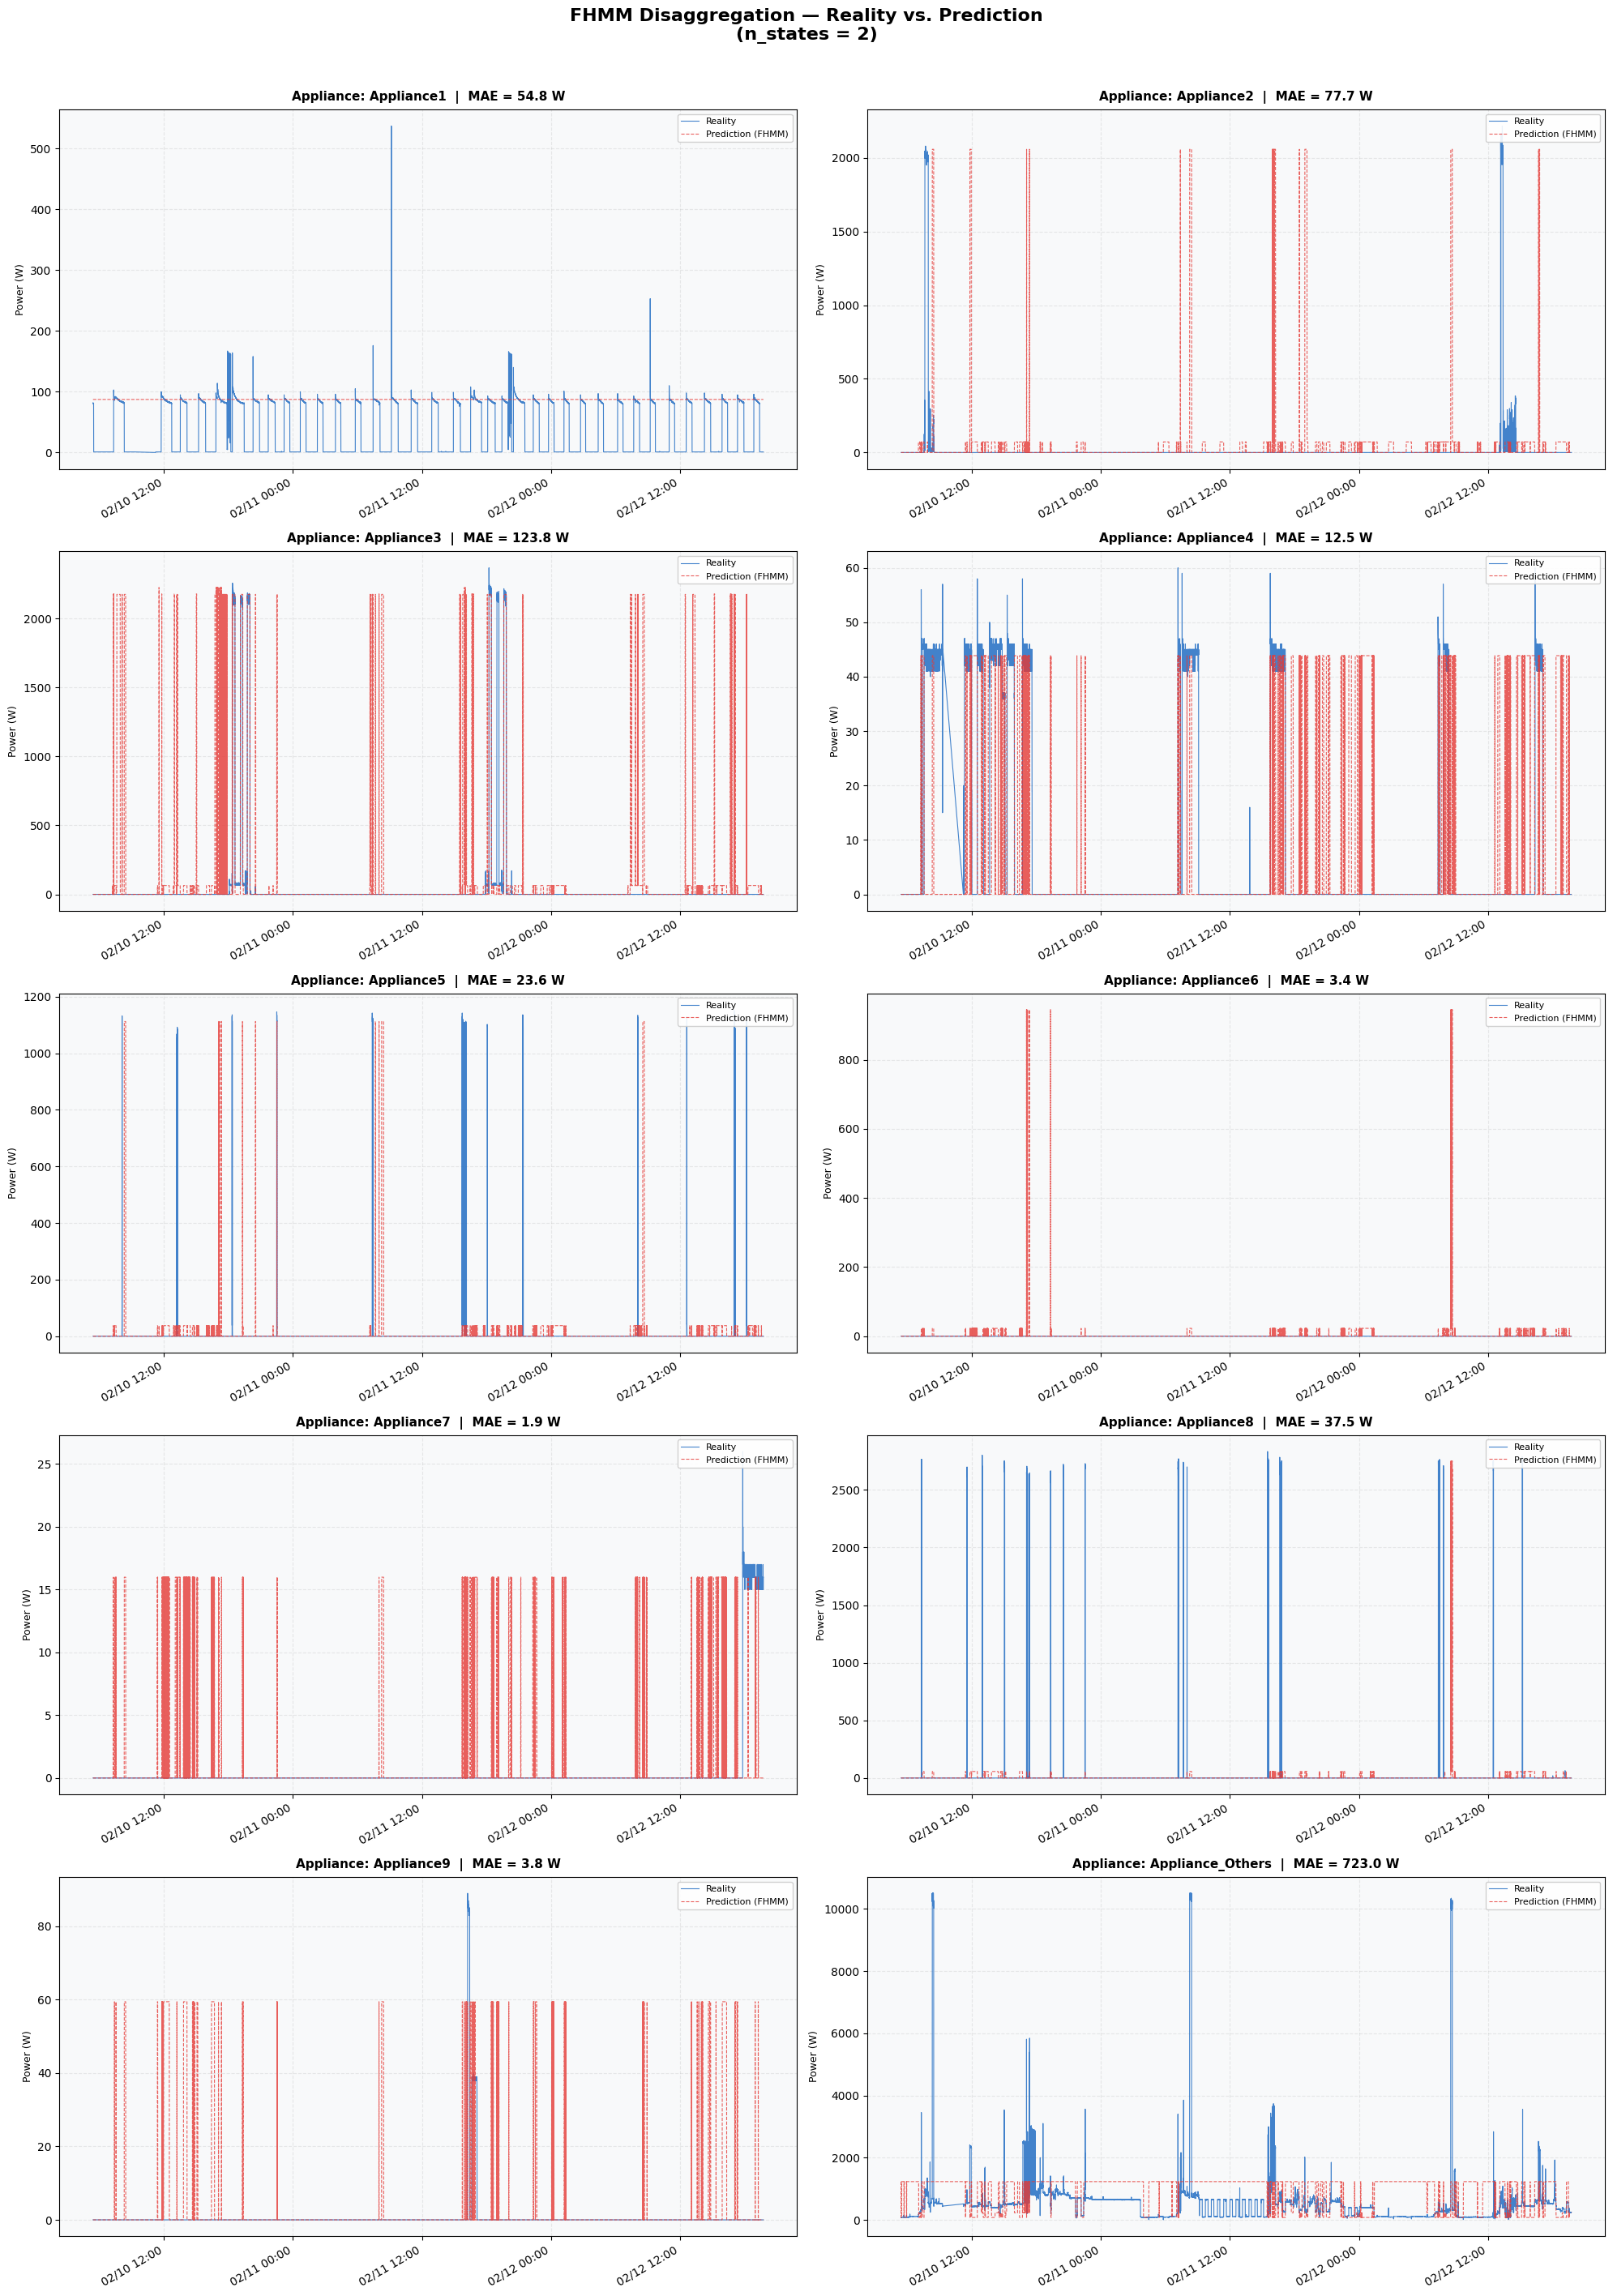

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# Đã bỏ .iloc[WINDOW_SIZE:] vì df_test giờ được lấy nguyên vẹn
time_test = df_test['Time'].reset_index(drop=True)

N_PLOT = min(32_400, len(time_test))

all_appliances = ['Appliance1', 'Appliance2', 'Appliance3',
                  'Appliance4', 'Appliance5', 'Appliance6',
                  'Appliance7', 'Appliance8', 'Appliance9',
                  'Appliance_Others']

colors_actual = '#1565C0'  
colors_pred   = '#E53935' 

fig, axes = plt.subplots(5, 2, figsize=(20, 28))
axes = axes.flatten()  # chuyển từ 2D array sang 1D

for i, col in enumerate(all_appliances):
    ax = axes[i]
    
    t = time_test[:N_PLOT]
    actual = y_test[col].values[:N_PLOT]
    predicted = y_pred_df[col].values[:N_PLOT]
    
    ax.plot(t, actual, 
            color=colors_actual, linewidth=0.8, alpha=0.8,
            label='Reality', zorder=2)
    
    ax.plot(t, predicted, 
            color=colors_pred, linewidth=0.8, alpha=0.8,
            label='Prediction (FHMM)', linestyle='--', zorder=3)

    mae_val = np.abs(actual - predicted).mean()
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    
    ax.set_title(f'Appliance: {col}  |  MAE = {mae_val:.1f} W', 
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('Power (W)', fontsize=9)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.25, linestyle='--')
    
    ax.set_facecolor('#F8F9FA')

for j in range(len(all_appliances), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'FHMM Disaggregation — Reality vs. Prediction\n'
             f'(n_states = {best_model.n_states})',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()

output_path = os.path.join(base_dir, 'notebooks/fhmm', 'fhmm_results.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')

plt.show()